In [74]:
!pip install wordcloud
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


%matplotlib inline
sns.set(style="whitegrid")





In [75]:
##Load the Dataset
df = pd.read_csv('salary_data.csv')

df.dropna(inplace=True)
df = df[df['salary'] > 0]

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L


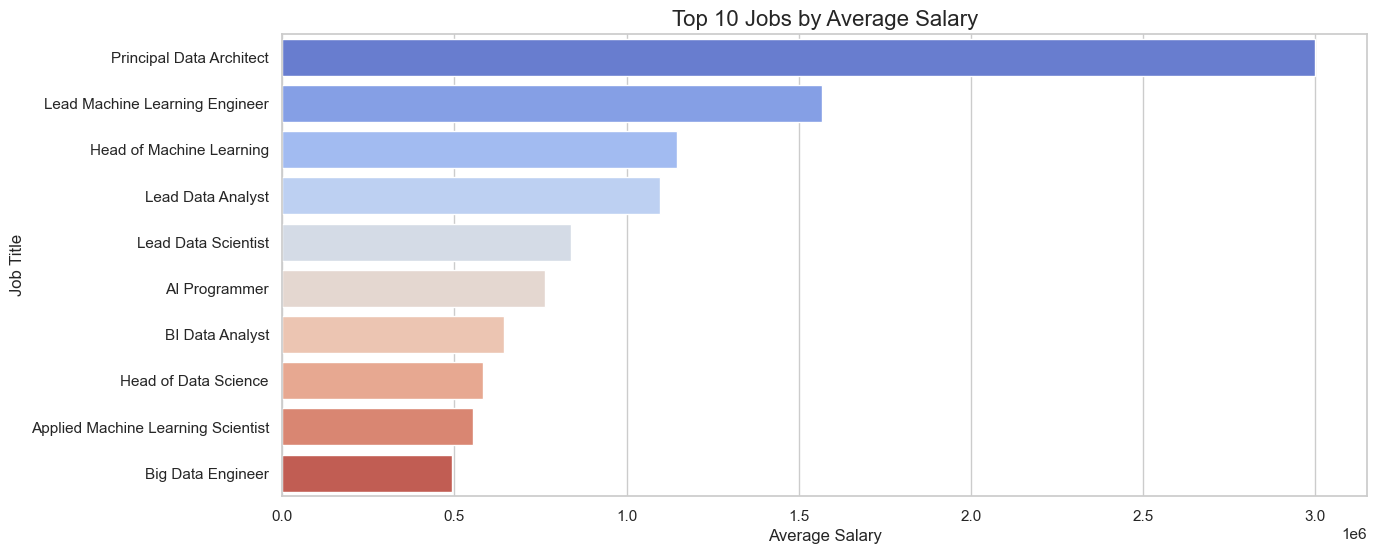

In [76]:
##Top 10 Jobs by Average Salary


top_jobs_df = top_jobs.reset_index()
top_jobs_df.columns = ['job_title', 'average_salary']

plt.figure(figsize=(14,6))
sns.barplot(
    data=top_jobs_df,
    x='average_salary',
    y='job_title',
    hue='job_title',     
    dodge=False,
    palette='coolwarm',
    legend=False           
)
plt.title('Top 10 Jobs by Average Salary', fontsize=16)
plt.xlabel('Average Salary')
plt.ylabel('Job Title')
plt.show()

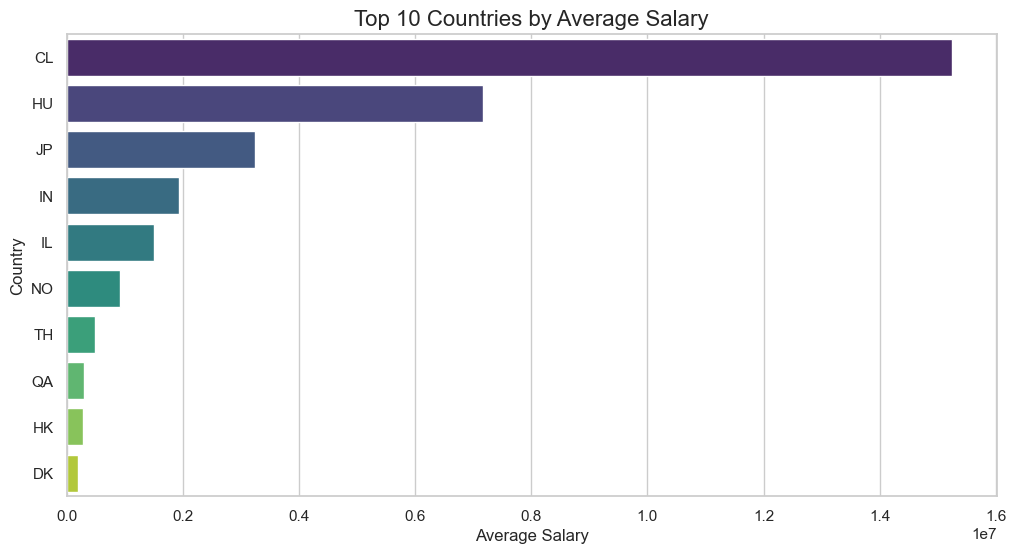

In [48]:
##TTop 10 Countries by Average Salary

top_countries_df = top_countries.reset_index()
top_countries_df.columns = ['country', 'average_salary']

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_countries_df,
    x='average_salary',
    y='country',
    hue='country',    
    dodge=False,
    palette='viridis',
    legend=False        
)
plt.title('Top 10 Countries by Average Salary', fontsize=16)
plt.xlabel('Average Salary')
plt.ylabel('Country')
plt.show()

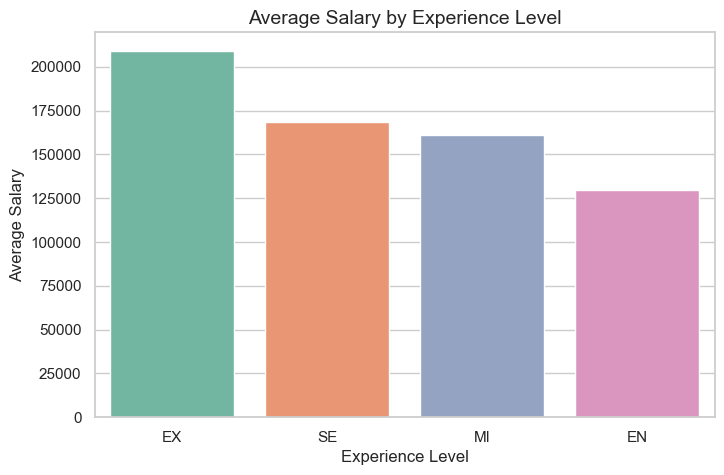

In [49]:
##Average Salary by Experience Level


avg_exp_df = avg_exp.reset_index()
avg_exp_df.columns = ['experience_level', 'average_salary']

plt.figure(figsize=(8,5))
sns.barplot(
    data=avg_exp_df,
    x='experience_level',
    y='average_salary',
    hue='experience_level',  
    dodge=False,
    palette='Set2',
    legend=False              
)
plt.title('Average Salary by Experience Level', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Average Salary')
plt.show()

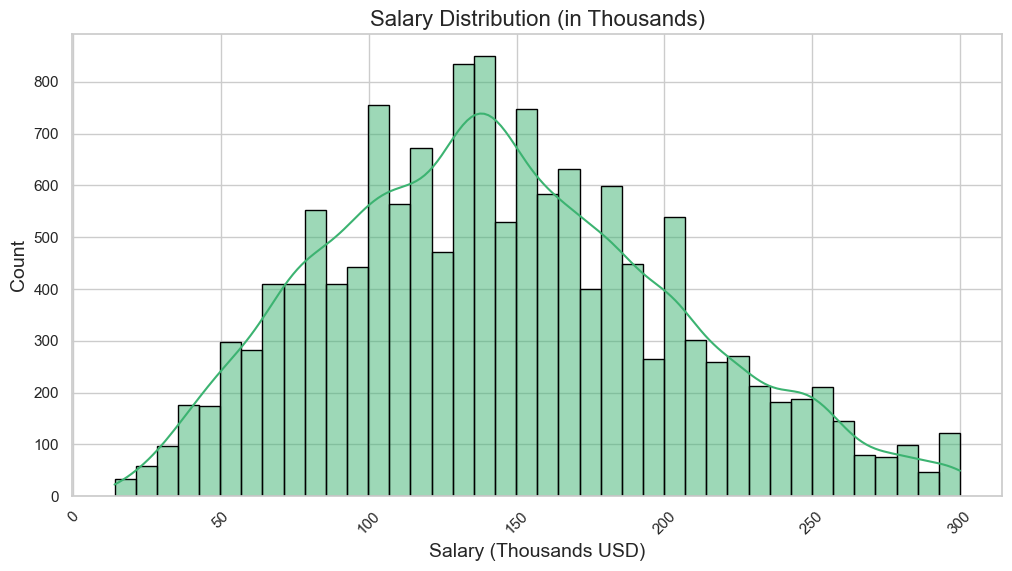

In [52]:
##Salary Distribution

df['salary_k'] = df['salary'] / 1000


df_hist = df[df['salary_k'] <= 300]

plt.figure(figsize=(12,6))
sns.histplot(
    df_hist['salary_k'], 
    bins=40,          
    kde=True, 
    color='mediumseagreen', 
    edgecolor='black'
)
plt.title('Salary Distribution (in Thousands)', fontsize=16)
plt.xlabel('Salary (Thousands USD)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.show()

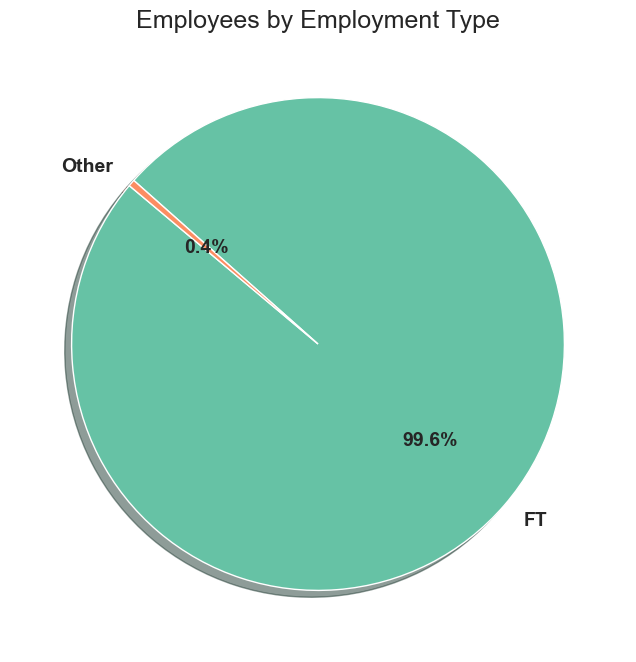

In [58]:
##Employment Type

employment_counts = df['employment_type'].value_counts()


threshold = 0.02 * employment_counts.sum()
employment_counts_mod = employment_counts.copy()
employment_counts_mod[employment_counts < threshold] = 0
other_count = employment_counts[employment_counts < threshold].sum()
if other_count > 0:
    employment_counts_mod['Other'] = other_count


employment_counts_mod = employment_counts_mod[employment_counts_mod > 0]


plt.figure(figsize=(8,8))
colors = sns.color_palette('Set2')[0:len(employment_counts_mod)]
plt.pie(
    employment_counts_mod,
    labels=employment_counts_mod.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    shadow=True,
    textprops={'fontsize':14, 'weight':'bold'}
)
plt.title('Employees by Employment Type', fontsize=18)
plt.show()

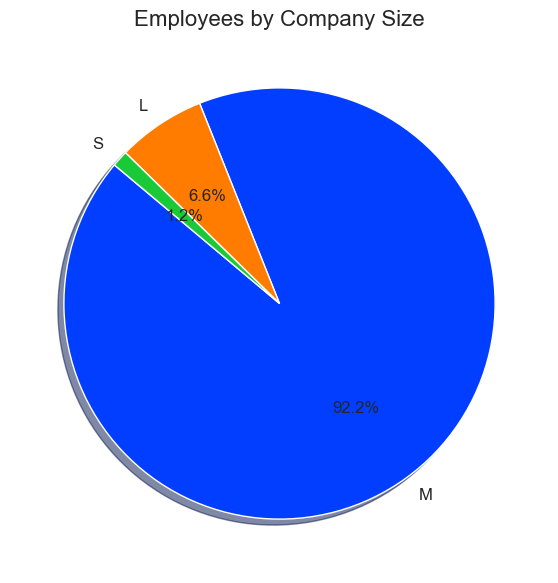

In [54]:
##Company Size
company_counts = df['company_size'].value_counts()

plt.figure(figsize=(7,7))
colors = sns.color_palette('bright')[0:len(company_counts)]
plt.pie(company_counts, labels=company_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, shadow=True, textprops={'fontsize':12})
plt.title('Employees by Company Size', fontsize=16)
plt.show()

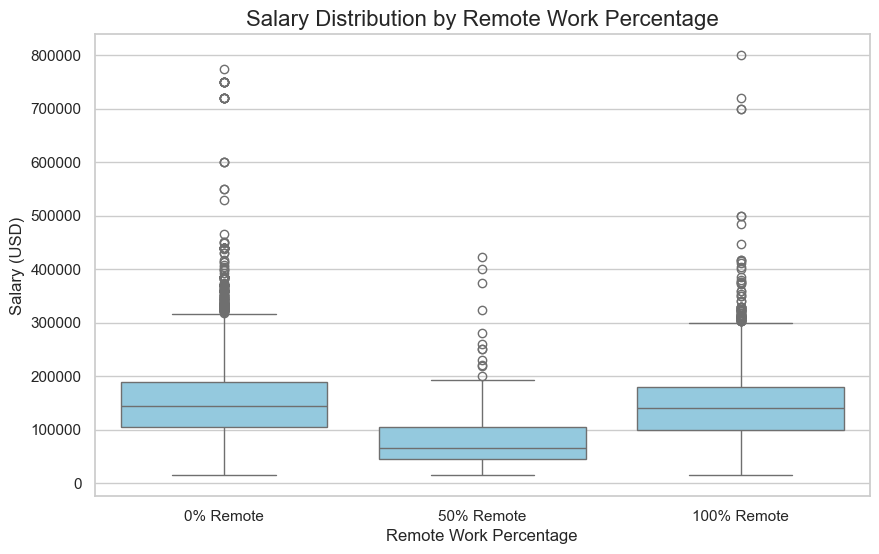

In [64]:
##Salary Distribution by Remote Work Percentage
plt.figure(figsize=(10,6))
sns.boxplot(
    x='remote_ratio', 
    y='salary_in_usd', 
    data=df, 
    color='skyblue' 
)
plt.title('Salary Distribution by Remote Work Percentage', fontsize=16)
plt.xlabel('Remote Work Percentage', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks([0,1,2], ['0% Remote', '50% Remote', '100% Remote'])
plt.show()

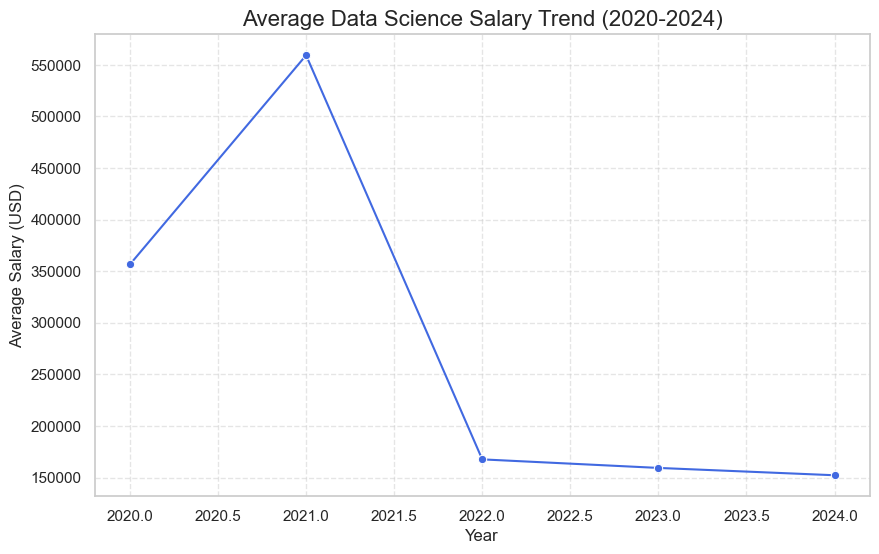

In [73]:
##Average Data Science Salary Trend (2020-2024)

avg_salary_year = df.groupby('work_year')['salary'].mean()


plt.figure(figsize=(10,6))
sns.lineplot(x=avg_salary_year.index, y=avg_salary_year.values, marker='o', color='royalblue')
plt.title('Average Data Science Salary Trend (2020-2024)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

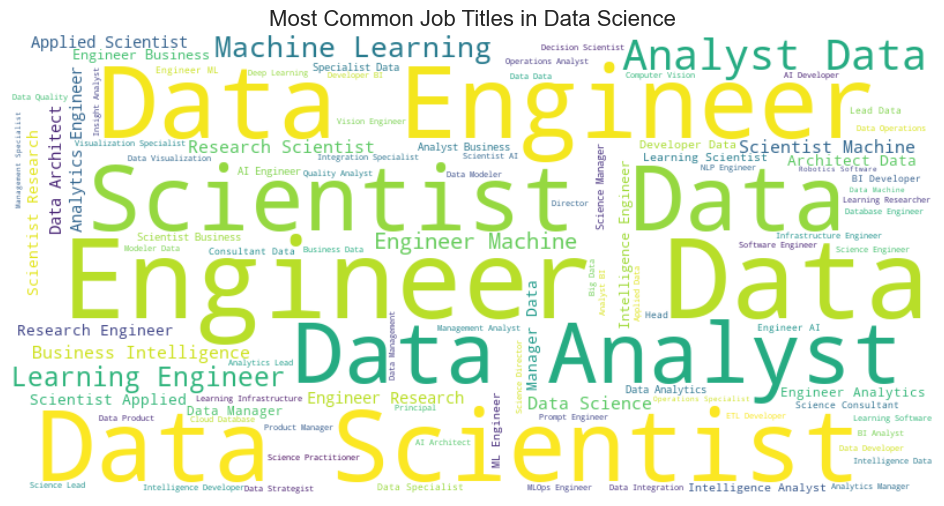

In [72]:
##Most Common Job Titles in Data Science

text = " ".join(title for title in df['job_title'].dropna())


wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(text)


plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title('Most Common Job Titles in Data Science', fontsize=16)
plt.show()

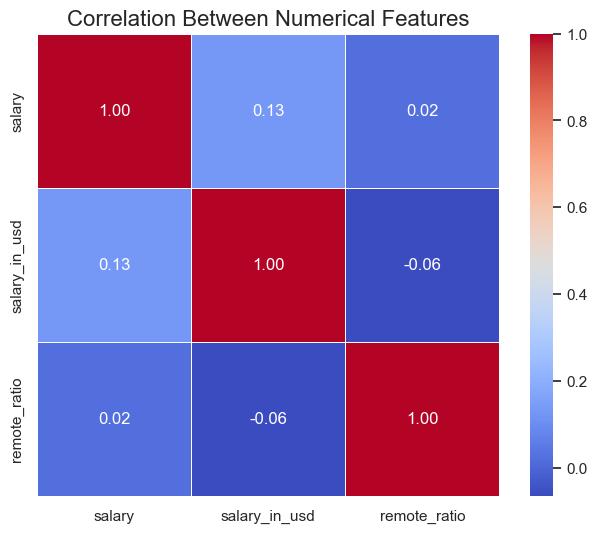

In [63]:
##Correlation Between Numerical Features

numeric_cols = ['salary', 'salary_in_usd', 'remote_ratio']


corr_matrix = df[numeric_cols].corr()


plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix, 
    annot=True,           
    cmap='coolwarm',      
    fmt=".2f",           
    linewidths=0.5,      
    square=True
)
plt.title('Correlation Between Numerical Features', fontsize=16)
plt.show()